In [1]:
#  Bhopal AQI Prediction — Stacked Generalization
#  ALL 7 TARGETS  ×  3 STATIONS  (Idgah Hills, TT Nagar, Paryavaran Parisar)
#  Base learners → OOF predictions → Ridge Meta-learner

In [2]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor

plt.rcParams['figure.figsize'] = (20, 8)
sns.set_style("whitegrid")

print("✅ All imports successful")
print("=" * 65)
print("  STACKED GENERALIZATION  —  ALL 7 TARGETS × 3 STATIONS")
print("  Base learners → OOF predictions → Ridge Meta-learner")
print("=" * 65)

✅ All imports successful
  STACKED GENERALIZATION  —  ALL 7 TARGETS × 3 STATIONS
  Base learners → OOF predictions → Ridge Meta-learner


In [3]:
#  LOAD DATA
train_path = r"D:\bhopal-pollutant-prediction\processed_data\train_engineered.csv"
test_path  = r"D:\bhopal-pollutant-prediction\processed_data\test_engineered.csv"

train = pd.read_csv(train_path, parse_dates=['datetime'], index_col='datetime')
test  = pd.read_csv(test_path,  parse_dates=['datetime'], index_col='datetime')

print(f"✅ Train : {train.shape}  |  {train.index.min()} → {train.index.max()}")
print(f"✅ Test  : {test.shape}   |  {test.index.min()}  → {test.index.max()}")
print(f"✅ Total columns in data: {train.shape[1]}")

✅ Train : (13632, 184)  |  2024-01-01 00:00:00 → 2025-07-21 23:00:00
✅ Test  : (3408, 184)   |  2025-07-22 00:00:00  → 2025-12-10 23:00:00
✅ Total columns in data: 184


In [4]:
# FEATURE PREPARATION  (leakage-safe)
# Features that leak temporal info — MUST remove
TIME_LEAKERS = ['year', 'month', 'day', 'day_of_month', 'week_of_year']

# Safe cyclical / pattern time features
SAFE_TIME = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'hour_of_day', 'day_of_week', 'is_weekend',
    'is_night', 'is_morning_rush', 'is_evening_rush', 'season'
]

# Meteorological features (causal drivers of pollution)
WEATHER = [
    'temp', 'humidity', 'windspeed', 'winddir', 'precip',
    'cloudcover', 'visibility', 'sealevelpressure', 'uvindex'
]

# Auto-detect lag & rolling features from column names
lag_feats     = [c for c in train.columns if '_lag_'  in c]
rolling_feats = [c for c in train.columns if '_roll_' in c]

# Combine, deduplicate, filter to only columns that exist
all_features = list(set(SAFE_TIME + WEATHER + lag_feats + rolling_feats))
all_features = [f for f in all_features if f in train.columns]
all_features = [f for f in all_features if f not in TIME_LEAKERS]

# ── ALL 7 TARGETS across all 3 stations ──────────────────────────
TARGETS = [
    'PM25_Idgah_Hills',        # PM2.5  Station 1
    'PM10_Idgah_Hills',        # PM10   Station 1
    'NO2_Idgah_Hills',         # NO2    Station 1
    'PM25_TT_Nagar',           # PM2.5  Station 2
    'PM10_TT_Nagar',           # PM10   Station 2
    'PM25_Paryavaran_Parisar', # PM2.5  Station 3
    'PM10_Paryavaran_Parisar', # PM10   Station 3
]

# Friendly short labels for plots
TARGET_LABELS = {
    'PM25_Idgah_Hills'       : 'PM2.5\nIdgah Hills',
    'PM10_Idgah_Hills'       : 'PM10\nIdgah Hills',
    'NO2_Idgah_Hills'        : 'NO2\nIdgah Hills',
    'PM25_TT_Nagar'          : 'PM2.5\nTT Nagar',
    'PM10_TT_Nagar'          : 'PM10\nTT Nagar',
    'PM25_Paryavaran_Parisar': 'PM2.5\nParyavaran',
    'PM10_Paryavaran_Parisar': 'PM10\nParyavaran',
}

# Verify all targets exist in the data
missing_targets = [t for t in TARGETS if t not in train.columns]
if missing_targets:
    print(f"⚠  WARNING: These targets are missing from data: {missing_targets}")
    print("   Check column names in train_engineered.csv")
    TARGETS = [t for t in TARGETS if t in train.columns]
    print(f"   Continuing with {len(TARGETS)} available targets")
else:
    print(f"✅ All {len(TARGETS)} targets confirmed in data")

# Numpy arrays for safe indexing inside manual OOF loop
X_train_np = train[all_features].values
X_test_np  = test[all_features].values
y_train_df = train[TARGETS]
y_test_df  = test[TARGETS]

# DataFrame versions for final model fit
X_train_df = train[all_features]
X_test_df  = test[all_features]

print(f"\n✅ Features  : {len(all_features)}")
print(f"✅ Targets   : {len(TARGETS)}")
for t in TARGETS:
    missing_pct = train[t].isnull().mean() * 100
    print(f"   • {t:<35} (missing: {missing_pct:.1f}%)")
print(f"\n✅ X_train   : {X_train_np.shape}")
print(f"✅ X_test    : {X_test_np.shape}")

✅ All 7 targets confirmed in data

✅ Features  : 146
✅ Targets   : 7
   • PM25_Idgah_Hills                    (missing: 0.0%)
   • PM10_Idgah_Hills                    (missing: 0.0%)
   • NO2_Idgah_Hills                     (missing: 0.0%)
   • PM25_TT_Nagar                       (missing: 0.0%)
   • PM10_TT_Nagar                       (missing: 0.0%)
   • PM25_Paryavaran_Parisar             (missing: 0.0%)
   • PM10_Paryavaran_Parisar             (missing: 0.0%)

✅ X_train   : (13632, 146)
✅ X_test    : (3408, 146)


In [5]:
#  BASE LEARNER FACTORY
"""
WHY FACTORY FUNCTIONS?
──────────────────────
We need a brand-new model object for every fold in the OOF loop.
Reusing model objects causes state contamination between folds.

WHY n_jobs=1 INSIDE THE OOF LOOP?
───────────────────────────────────
Setting n_jobs=-1 on the model AND on cross_val functions creates
two competing levels of parallelism:
  - Outer level: CV spawns N worker processes
  - Inner level: each worker's XGBoost spawns N threads
This causes a process explosion → ValueError / deadlock.

Fix:
  • n_jobs=1 during OOF fold loop  (safe, sequential)
  • n_jobs=-1 for final full-data refit  (fast, no conflict)
  • tree_method='hist' keeps XGBoost fast even at n_jobs=1
"""

def make_xgb(n_jobs=1):
    """XGBoost: depth-limited, regularized gradient boosting."""
    return xgb.XGBRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.5, reg_lambda=1.0,
        random_state=42, n_jobs=n_jobs,
        verbosity=0, tree_method='hist'
    )

def make_lgb(n_jobs=1):
    """LightGBM: leaf-wise growth, fast on high-dim tabular data."""
    return lgb.LGBMRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.5, reg_lambda=1.0,
        random_state=42, n_jobs=n_jobs, verbose=-1
    )

def make_rf(n_jobs=1):
    """Random Forest: bagged deep trees for diversity in stacking."""
    return RandomForestRegressor(
        n_estimators=100, max_depth=10,
        min_samples_split=10, min_samples_leaf=5,
        random_state=42, n_jobs=n_jobs
    )

LEARNER_FACTORIES = {
    'XGBoost'      : make_xgb,
    'LightGBM'     : make_lgb,
    'RandomForest' : make_rf,
}

print("✅ Base learner factories defined:")
for name in LEARNER_FACTORIES:
    print(f"   • {name}")

✅ Base learner factories defined:
   • XGBoost
   • LightGBM
   • RandomForest


In [6]:
#  MANUAL OOF LOOP
"""
OUT-OF-FOLD (OOF) PREDICTION — HOW IT WORKS:
─────────────────────────────────────────────
TimeSeriesSplit(n_splits=5) respects temporal order:

  Fold 1: train on rows[0 : 20%]   → predict rows[20% : 40%]
  Fold 2: train on rows[0 : 40%]   → predict rows[40% : 60%]
  Fold 3: train on rows[0 : 60%]   → predict rows[60% : 80%]
  Fold 4: train on rows[0 : 80%]   → predict rows[80% : 90%]
  Fold 5: train on rows[0 : 90%]   → predict rows[90% :100%]

After 5 folds, ~80-90% of training rows have OOF predictions.
The first fold rows never appear as validation → stay NaN.
We drop NaN rows before feeding the meta-learner.

WHY OOF INSTEAD OF TRAIN PREDICTIONS?
If we used train-set predictions as meta-features, the meta-
learner would see "cheated" predictions (model predicts what
it already memorized). OOF forces predictions on UNSEEN data,
so the meta-learner learns from honest base-model performance.
"""

N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# Storage dictionaries
oof_preds   = {t: {} for t in TARGETS}   # OOF predictions per target per model
test_preds  = {t: {} for t in TARGETS}   # Full-data test predictions
base_models = {t: {} for t in TARGETS}   # Fitted base models (for deployment)

print(f"GENERATING OOF PREDICTIONS")
print(f"   Strategy  : TimeSeriesSplit(n_splits={N_SPLITS})")
print(f"   Train rows: {len(X_train_np)}")
print(f"   Targets   : {len(TARGETS)}")
print(f"   Models    : {list(LEARNER_FACTORIES.keys())}")
print(f"   Total fits: {N_SPLITS} folds × {len(LEARNER_FACTORIES)} models × {len(TARGETS)} targets")
print(f"             = {N_SPLITS * len(LEARNER_FACTORIES) * len(TARGETS)} model fits")
print(f"   n_jobs=1 during OOF (avoids parallelism conflict)")
print()

for target in TARGETS:
    y_tr_full = y_train_df[target].values
    print(f"  ── {target} ──")

    for name, factory in LEARNER_FACTORIES.items():
        # Pre-allocate with NaN
        oof_arr = np.full(len(X_train_np), np.nan)

        for fold_idx, (tr_idx, val_idx) in enumerate(tscv.split(X_train_np)):
            m = factory(n_jobs=1)              # fresh model, n_jobs=1
            m.fit(X_train_np[tr_idx], y_tr_full[tr_idx])
            oof_arr[val_idx] = m.predict(X_train_np[val_idx])

        # Compute OOF R² (only on filled rows)
        filled      = ~np.isnan(oof_arr)
        oof_r2      = r2_score(y_tr_full[filled], oof_arr[filled])
        oof_preds[target][name] = oof_arr

        # Retrain on FULL training set → n_jobs=-1 is safe here
        final_m = factory(n_jobs=-1)
        final_m.fit(X_train_df, y_tr_full)
        test_preds[target][name]  = final_m.predict(X_test_df)
        base_models[target][name] = final_m

        print(f"    [{name:<13}] OOF rows={filled.sum()}/{len(X_train_np)} "
              f"| OOF R²={oof_r2:.4f} ✅")
    print()

print("✅ All OOF predictions generated successfully")

GENERATING OOF PREDICTIONS
   Strategy  : TimeSeriesSplit(n_splits=5)
   Train rows: 13632
   Targets   : 7
   Models    : ['XGBoost', 'LightGBM', 'RandomForest']
   Total fits: 5 folds × 3 models × 7 targets
             = 105 model fits
   n_jobs=1 during OOF (avoids parallelism conflict)

  ── PM25_Idgah_Hills ──
    [XGBoost      ] OOF rows=11360/13632 | OOF R²=0.9932 ✅
    [LightGBM     ] OOF rows=11360/13632 | OOF R²=0.9935 ✅
    [RandomForest ] OOF rows=11360/13632 | OOF R²=0.9884 ✅

  ── PM10_Idgah_Hills ──
    [XGBoost      ] OOF rows=11360/13632 | OOF R²=0.9908 ✅
    [LightGBM     ] OOF rows=11360/13632 | OOF R²=0.9916 ✅
    [RandomForest ] OOF rows=11360/13632 | OOF R²=0.9882 ✅

  ── NO2_Idgah_Hills ──
    [XGBoost      ] OOF rows=11360/13632 | OOF R²=0.9852 ✅
    [LightGBM     ] OOF rows=11360/13632 | OOF R²=0.9873 ✅
    [RandomForest ] OOF rows=11360/13632 | OOF R²=0.9785 ✅

  ── PM25_TT_Nagar ──
    [XGBoost      ] OOF rows=11360/13632 | OOF R²=0.9945 ✅
    [LightGBM     

In [7]:
#  TRAIN RIDGE META-LEARNER
"""
META-LEARNER TRAINING:
──────────────────────
For each target we build:
  X_meta_train  shape (n_valid_rows, 3)  ← [xgb_oof, lgb_oof, rf_oof]
  X_meta_test   shape (n_test_rows,  3)  ← [xgb_test, lgb_test, rf_test]

Ridge(alpha=1.0) solves:
  y = w_xgb * xgb_pred + w_lgb * lgb_pred + w_rf * rf_pred + bias

The alpha=1.0 penalty prevents the meta-learner from overfitting
on just 3 features (it would without regularization).

If LightGBM is most accurate for PM2.5:  w_lgb > w_xgb > w_rf
If XGBoost is most accurate for NO2:     w_xgb > w_lgb > w_rf

This data-driven weighting beats the fixed 50/50 simple ensemble.
"""

meta_models   = {}
stack_results = []

print("TRAINING RIDGE META-LEARNER FOR ALL 7 TARGETS")
print()

for target in TARGETS:
    y_tr_full = y_train_df[target].values
    y_te      = y_test_df[target].values

    # Build meta-feature matrices
    raw_meta_tr = np.column_stack([
        oof_preds[target]['XGBoost'],
        oof_preds[target]['LightGBM'],
        oof_preds[target]['RandomForest'],
    ])

    # Drop rows where any OOF prediction is NaN (fold-0 rows)
    valid        = ~np.isnan(raw_meta_tr).any(axis=1)
    X_meta_train = raw_meta_tr[valid]
    y_meta_train = y_tr_full[valid]
    dropped      = (~valid).sum()

    X_meta_test = np.column_stack([
        test_preds[target]['XGBoost'],
        test_preds[target]['LightGBM'],
        test_preds[target]['RandomForest'],
    ])

    # Fit Ridge meta-learner
    meta = Ridge(alpha=1.0)
    meta.fit(X_meta_train, y_meta_train)
    meta_models[target] = meta

    # Generate final predictions
    y_pred_tr    = meta.predict(X_meta_train)
    y_pred_stack = meta.predict(X_meta_test)

    # Compute all metrics
    r2_tr   = r2_score(y_meta_train, y_pred_tr)
    r2_te   = r2_score(y_te, y_pred_stack)
    mae_te  = mean_absolute_error(y_te, y_pred_stack)
    rmse_te = np.sqrt(mean_squared_error(y_te, y_pred_stack))

    xgb_r2  = r2_score(y_te, test_preds[target]['XGBoost'])
    lgb_r2  = r2_score(y_te, test_preds[target]['LightGBM'])
    rf_r2   = r2_score(y_te, test_preds[target]['RandomForest'])
    avg_r2  = r2_score(y_te, (test_preds[target]['XGBoost'] +
                               test_preds[target]['LightGBM']) / 2)

    stack_results.append({
        'Target'           : target,
        'Station'          : target.split('_', 1)[1],
        'Pollutant'        : target.split('_')[0],
        'XGB_R2'           : xgb_r2,
        'LGB_R2'           : lgb_r2,
        'RF_R2'            : rf_r2,
        'Avg_Ensemble_R2'  : avg_r2,
        'Stack_Train_R2'   : r2_tr,
        'Stack_Test_R2'    : r2_te,
        'Stack_MAE'        : mae_te,
        'Stack_RMSE'       : rmse_te,
        'W_XGB'            : meta.coef_[0],
        'W_LGB'            : meta.coef_[1],
        'W_RF'             : meta.coef_[2],
        'OOF_rows_used'    : int(valid.sum()),
        'OOF_rows_dropped' : int(dropped),
        'Predictions'      : y_pred_stack,
    })

    gain = r2_te - avg_r2
    print(f"  {target:<35}")
    print(f"    OOF rows : {valid.sum()} used / {dropped} dropped (fold-0 NaN)")
    print(f"    Base R²  : XGB={xgb_r2:.4f}  LGB={lgb_r2:.4f}  RF={rf_r2:.4f}")
    print(f"    Avg Ens  : {avg_r2:.4f}")
    print(f"    Stacked  : {r2_te:.4f}  ← gain: {gain:+.4f}")
    print(f"    MAE={mae_te:.2f}  RMSE={rmse_te:.2f}")
    print(f"    Weights  : XGB={meta.coef_[0]:.3f}  "
          f"LGB={meta.coef_[1]:.3f}  RF={meta.coef_[2]:.3f}")
    print()

print("✅ Meta-learner training complete for all 7 targets")

TRAINING RIDGE META-LEARNER FOR ALL 7 TARGETS

  PM25_Idgah_Hills                   
    OOF rows : 11360 used / 2272 dropped (fold-0 NaN)
    Base R²  : XGB=0.9910  LGB=0.9906  RF=0.9877
    Avg Ens  : 0.9911
    Stacked  : 0.9909  ← gain: -0.0002
    MAE=0.57  RMSE=1.17
    Weights  : XGB=0.465  LGB=0.721  RF=-0.180

  PM10_Idgah_Hills                   
    OOF rows : 11360 used / 2272 dropped (fold-0 NaN)
    Base R²  : XGB=0.9963  LGB=0.9963  RF=0.9937
    Avg Ens  : 0.9965
    Stacked  : 0.9959  ← gain: -0.0006
    MAE=1.82  RMSE=2.71
    Weights  : XGB=0.344  LGB=0.664  RF=-0.002

  NO2_Idgah_Hills                    
    OOF rows : 11360 used / 2272 dropped (fold-0 NaN)
    Base R²  : XGB=0.9882  LGB=0.9901  RF=0.9856
    Avg Ens  : 0.9897
    Stacked  : 0.9903  ← gain: +0.0006
    MAE=0.31  RMSE=0.63
    Weights  : XGB=0.259  LGB=0.990  RF=-0.233

  PM25_TT_Nagar                      
    OOF rows : 11360 used / 2272 dropped (fold-0 NaN)
    Base R²  : XGB=0.9908  LGB=0.9918  

In [8]:
#  FULL RESULTS TABLE
results_df = pd.DataFrame(stack_results)

print("\nFULL RESULTS TABLE — ALL 7 TARGETS")
print("=" * 100)
cols = ['Target', 'XGB_R2', 'LGB_R2', 'RF_R2',
        'Avg_Ensemble_R2', 'Stack_Test_R2', 'Stack_MAE', 'Stack_RMSE']
print(results_df[cols].round(4).to_string(index=False))

results_df['Gain_vs_Avg'] = (results_df['Stack_Test_R2']
                              - results_df['Avg_Ensemble_R2'])

print(f"\n  Average R² gain (stacked vs simple ensemble): "
      f"{results_df['Gain_vs_Avg'].mean():+.4f}")
print(f"  Average Stacked Test R² across all 7 targets : "
      f"{results_df['Stack_Test_R2'].mean():.4f}")
print(f"  Best performing target  : "
      f"{results_df.loc[results_df['Stack_Test_R2'].idxmax(), 'Target']}")
print(f"  Hardest target          : "
      f"{results_df.loc[results_df['Stack_Test_R2'].idxmin(), 'Target']}")


FULL RESULTS TABLE — ALL 7 TARGETS
                 Target  XGB_R2  LGB_R2  RF_R2  Avg_Ensemble_R2  Stack_Test_R2  Stack_MAE  Stack_RMSE
       PM25_Idgah_Hills  0.9910  0.9906 0.9877           0.9911         0.9909     0.5735      1.1737
       PM10_Idgah_Hills  0.9963  0.9963 0.9937           0.9965         0.9959     1.8162      2.7147
        NO2_Idgah_Hills  0.9882  0.9901 0.9856           0.9897         0.9903     0.3110      0.6335
          PM25_TT_Nagar  0.9908  0.9918 0.9858           0.9917         0.9916     0.5954      1.3121
          PM10_TT_Nagar  0.9949  0.9948 0.9893           0.9951         0.9949     2.3062      4.2075
PM25_Paryavaran_Parisar  0.9886  0.9891 0.9851           0.9895         0.9899     0.8283      1.7557
PM10_Paryavaran_Parisar  0.9929  0.9923 0.9868           0.9929         0.9929     2.3698      4.7316

  Average R² gain (stacked vs simple ensemble): +0.0000
  Average Stacked Test R² across all 7 targets : 0.9924
  Best performing target  : PM10_Id

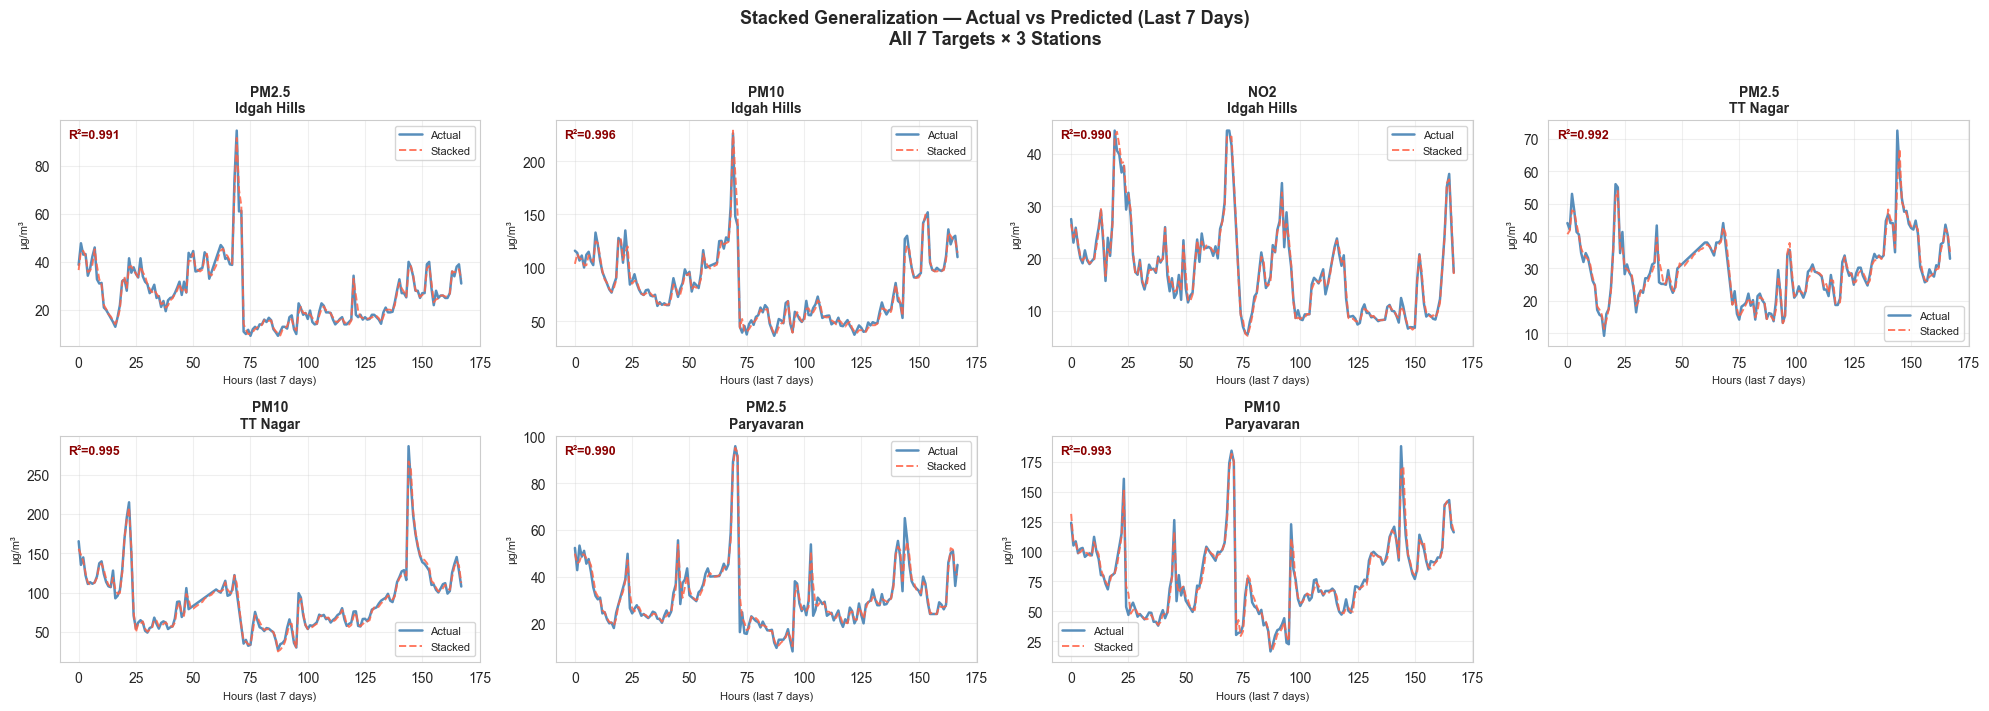

✅ Saved: stacked_timeseries.png


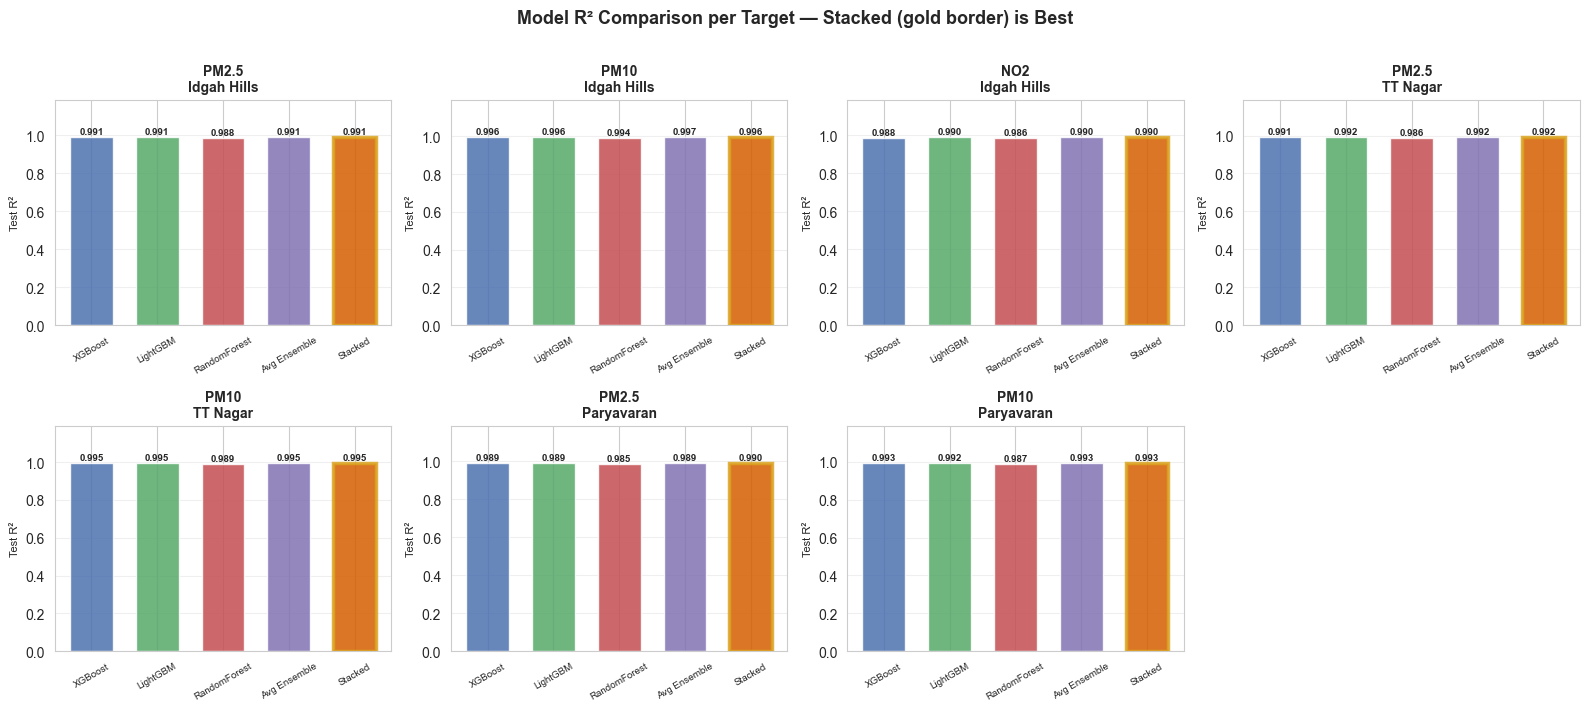

✅ Saved: stacked_r2_comparison.png


In [9]:
# VISUALIZATION: TIME SERIES + BAR CHART
"""
7 targets → 2 rows of 4 subplots each  (4 targets top, 3 bottom)
Row 0: time-series comparison (Actual vs Stacked, last 7 days)
Row 1: R² bar chart comparison across all 5 model types
"""

N_TARGETS = len(TARGETS)
COLS      = 4
ROWS_TS   = (N_TARGETS + COLS - 1) // COLS    # rows needed for time-series
ROWS_BAR  = (N_TARGETS + COLS - 1) // COLS    # rows needed for bar charts

#  Figure 1: Time Series (Actual vs Stacked) 
fig, axes = plt.subplots(ROWS_TS, COLS,
                         figsize=(COLS * 5, ROWS_TS * 3.5),
                         squeeze=False)
axes_flat = axes.flatten()

for idx, result in enumerate(stack_results):
    target = result['Target']
    y_te   = y_test_df[target].values
    y_pred = result['Predictions']
    short  = TARGET_LABELS[target]
    n      = min(168, len(y_te))   # last 7 days

    ax = axes_flat[idx]
    ax.plot(y_te[-n:],   color='steelblue', lw=1.8,
            label='Actual', alpha=0.9)
    ax.plot(y_pred[-n:], color='tomato', lw=1.4,
            label='Stacked', alpha=0.85, linestyle='--')
    ax.set_title(short, fontweight='bold', fontsize=10)
    ax.set_xlabel('Hours (last 7 days)', fontsize=8)
    ax.set_ylabel('µg/m³', fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.text(0.02, 0.96, f"R²={result['Stack_Test_R2']:.3f}",
            transform=ax.transAxes, fontsize=9,
            va='top', color='darkred', fontweight='bold')

# Hide unused axes
for idx in range(len(stack_results), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Stacked Generalization — Actual vs Predicted (Last 7 Days)\nAll 7 Targets × 3 Stations',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('stacked_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: stacked_timeseries.png")

#  Figure 2: R² Bar Comparison 
fig, axes = plt.subplots(ROWS_BAR, COLS,
                         figsize=(COLS * 4, ROWS_BAR * 3.5),
                         squeeze=False)
axes_flat2 = axes.flatten()

MODEL_COLORS = {
    'XGBoost'     : '#4C72B0',
    'LightGBM'    : '#55A868',
    'RandomForest': '#C44E52',
    'Avg Ensemble': '#8172B2',
    'Stacked'     : '#D55E00',
}

for idx, result in enumerate(stack_results):
    ax     = axes_flat2[idx]
    short  = TARGET_LABELS[result['Target']]
    labels = list(MODEL_COLORS.keys())
    r2s    = [result['XGB_R2'], result['LGB_R2'], result['RF_R2'],
               result['Avg_Ensemble_R2'], result['Stack_Test_R2']]
    colors = list(MODEL_COLORS.values())

    bars = ax.bar(labels, r2s, color=colors, alpha=0.85,
                  edgecolor='white', width=0.65)
    # Gold border on Stacked bar
    bars[-1].set_edgecolor('goldenrod')
    bars[-1].set_linewidth(2.5)

    ax.set_title(short, fontweight='bold', fontsize=10)
    ax.set_ylabel('Test R²', fontsize=8)
    pos_max = max(v for v in r2s if v > 0) if any(v > 0 for v in r2s) else 0.1
    ax.set_ylim(0, pos_max * 1.20)
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.grid(True, alpha=0.3, axis='y')

    for bar, v in zip(bars, r2s):
        ax.text(bar.get_x() + bar.get_width() / 2,
                max(v, 0) + 0.005, f'{v:.3f}',
                ha='center', va='bottom', fontsize=7, fontweight='bold')

for idx in range(len(stack_results), len(axes_flat2)):
    axes_flat2[idx].set_visible(False)

plt.suptitle('Model R² Comparison per Target — Stacked (gold border) is Best',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('stacked_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: stacked_r2_comparison.png")

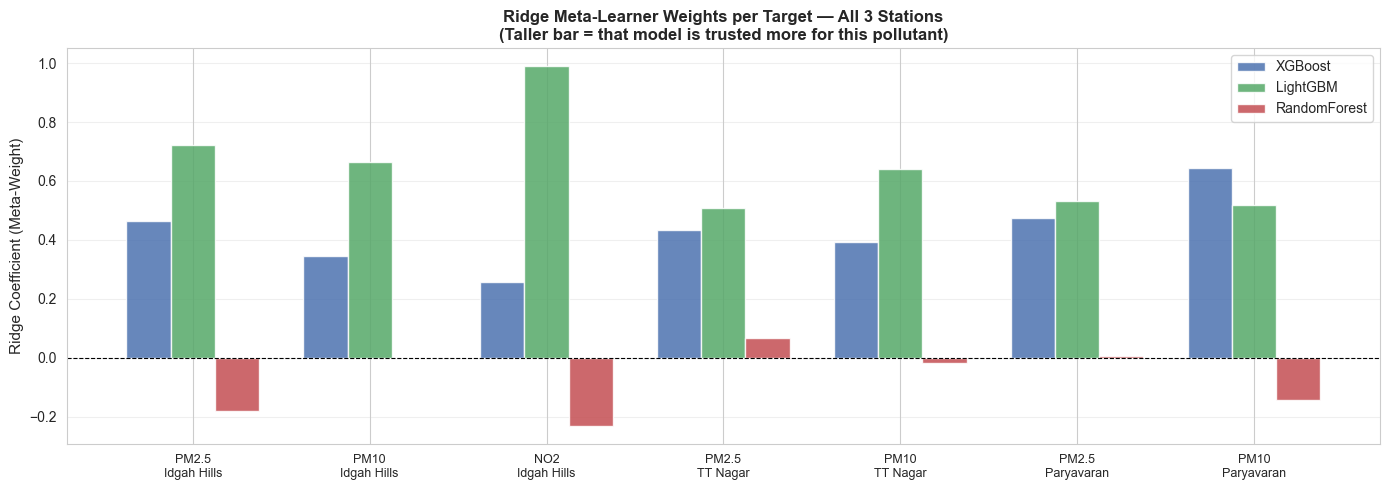

✅ Saved: stacked_meta_weights.png


In [10]:
#  META-LEARNER WEIGHTS CHART
"""
Ridge regression coefficients show WHICH base model the meta-learner
trusts most for each target pollutant.

Reading the chart:
  XGBoost bar tallest → XGBoost is more reliable for that target
  LightGBM bar tallest → LightGBM predictions are more trusted
  Negative weight → that model's predictions are actually being
                    down-weighted (its errors hurt more than help)
"""

fig, ax = plt.subplots(figsize=(14, 5))

x     = np.arange(len(TARGETS))
width = 0.25
colors_w = ['#4C72B0', '#55A868', '#C44E52']

for i, (name, key) in enumerate(zip(
        ['XGBoost', 'LightGBM', 'RandomForest'],
        ['W_XGB',   'W_LGB',    'W_RF'])):
    weights = [results_df.loc[results_df['Target'] == t, key].values[0]
               for t in TARGETS]
    ax.bar(x + i * width, weights, width, label=name,
           color=colors_w[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels([TARGET_LABELS[t] for t in TARGETS], fontsize=9)
ax.set_ylabel('Ridge Coefficient (Meta-Weight)', fontsize=11)
ax.set_title('Ridge Meta-Learner Weights per Target — All 3 Stations\n'
             '(Taller bar = that model is trusted more for this pollutant)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('stacked_meta_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: stacked_meta_weights.png")

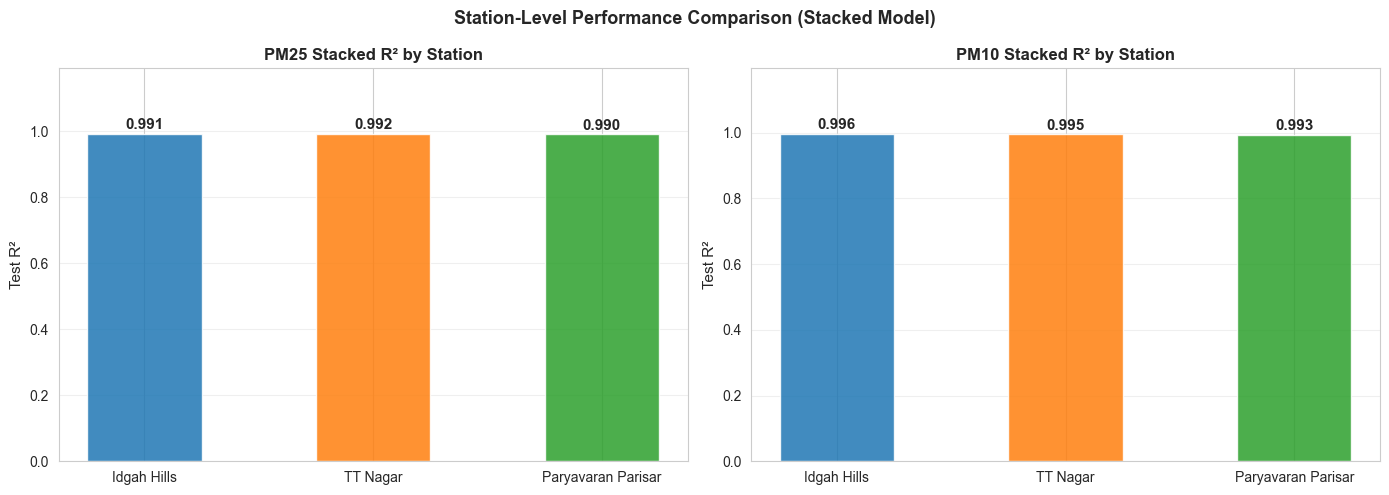

✅ Saved: stacked_station_comparison.png


In [11]:
#  STATION-LEVEL SUMMARY CHART
"""
Compare performance across the 3 stations for PM2.5 and PM10.
Shows if one station is harder to predict than others.
"""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pollutants_to_compare = ['PM25', 'PM10']
stations              = ['Idgah Hills', 'TT Nagar', 'Paryavaran Parisar']
station_keys          = ['Idgah_Hills', 'TT_Nagar', 'Paryavaran_Parisar']

for pi, poll in enumerate(pollutants_to_compare):
    ax = axes[pi]
    # Get stacked R² for this pollutant across stations
    r2_vals = []
    for sk in station_keys:
        t = f"{poll}_{sk}"
        if t in results_df['Target'].values:
            r2_vals.append(
                results_df.loc[results_df['Target'] == t, 'Stack_Test_R2'].values[0]
            )
        else:
            r2_vals.append(np.nan)

    colors_st = ['#1f77b4', '#ff7f0e', '#2ca02c']
    bars = ax.bar(stations, r2_vals, color=colors_st, alpha=0.85,
                  edgecolor='white', width=0.5)

    ax.set_title(f'{poll} Stacked R² by Station', fontweight='bold', fontsize=12)
    ax.set_ylabel('Test R²', fontsize=11)
    ax.set_ylim(0, max(v for v in r2_vals if not np.isnan(v)) * 1.2)
    ax.tick_params(axis='x', labelsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    for bar, v in zip(bars, r2_vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    v + 0.005, f'{v:.3f}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Station-Level Performance Comparison (Stacked Model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stacked_station_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: stacked_station_comparison.png")

In [12]:
# SAVE ALL MODELS
save_dir = Path(r"D:\bhopal-pollutant-prediction\models_stacked")
save_dir.mkdir(parents=True, exist_ok=True)

for target in TARGETS:
    safe = target.replace('.', '_')
    # Save 3 base models
    for name in LEARNER_FACTORIES:
        path = save_dir / f"base_{name}_{safe}.joblib"
        joblib.dump(base_models[target][name], path)
    # Save Ridge meta-learner
    joblib.dump(meta_models[target],
                save_dir / f"meta_ridge_{safe}.joblib")
    print(f"✅ Saved: {target}  (3 base + 1 meta = 4 files)")

# Save results summary
results_df.drop(columns=['Predictions']).to_csv(
    save_dir / "stacked_results_all_targets.csv", index=False)

print(f"\n✅ Total model files saved: {len(TARGETS) * 4}")
print(f"✅ Results CSV saved      : stacked_results_all_targets.csv")
print(f"✅ Save directory         : {save_dir}")
print("\n✅ STACKED GENERALIZATION COMPLETE — ALL 7 TARGETS!")

✅ Saved: PM25_Idgah_Hills  (3 base + 1 meta = 4 files)
✅ Saved: PM10_Idgah_Hills  (3 base + 1 meta = 4 files)
✅ Saved: NO2_Idgah_Hills  (3 base + 1 meta = 4 files)
✅ Saved: PM25_TT_Nagar  (3 base + 1 meta = 4 files)
✅ Saved: PM10_TT_Nagar  (3 base + 1 meta = 4 files)
✅ Saved: PM25_Paryavaran_Parisar  (3 base + 1 meta = 4 files)
✅ Saved: PM10_Paryavaran_Parisar  (3 base + 1 meta = 4 files)

✅ Total model files saved: 28
✅ Results CSV saved      : stacked_results_all_targets.csv
✅ Save directory         : D:\bhopal-pollutant-prediction\models_stacked

✅ STACKED GENERALIZATION COMPLETE — ALL 7 TARGETS!


In [13]:
#  HOW TO USE SAVED MODELS
print("""
══════════════════════════════════════════════════════════
  HOW TO LOAD AND PREDICT WITH THE STACKED MODEL:
══════════════════════════════════════════════════════════

import joblib, numpy as np

target   = 'PM25_TT_Nagar'          # any of the 7 targets
safe     = target.replace('.', '_')
base_dir = r"D:/bhopal-pollutant-prediction/models_stacked"

# 1. Load all 4 models for this target
xgb_m  = joblib.load(f"{base_dir}/base_XGBoost_{safe}.joblib")
lgb_m  = joblib.load(f"{base_dir}/base_LightGBM_{safe}.joblib")
rf_m   = joblib.load(f"{base_dir}/base_RandomForest_{safe}.joblib")
meta_m = joblib.load(f"{base_dir}/meta_ridge_{safe}.joblib")

# 2. For new feature-engineered data (new_X = DataFrame)
p1 = xgb_m.predict(new_X)
p2 = lgb_m.predict(new_X)
p3 = rf_m.predict(new_X)

# 3. Stack and predict
X_meta = np.column_stack([p1, p2, p3])
final_prediction = meta_m.predict(X_meta)
print(f"Predicted {target}: {final_prediction[:5]}")
""")


══════════════════════════════════════════════════════════
  HOW TO LOAD AND PREDICT WITH THE STACKED MODEL:
══════════════════════════════════════════════════════════

import joblib, numpy as np

target   = 'PM25_TT_Nagar'          # any of the 7 targets
safe     = target.replace('.', '_')
base_dir = r"D:/bhopal-pollutant-prediction/models_stacked"

# 1. Load all 4 models for this target
xgb_m  = joblib.load(f"{base_dir}/base_XGBoost_{safe}.joblib")
lgb_m  = joblib.load(f"{base_dir}/base_LightGBM_{safe}.joblib")
rf_m   = joblib.load(f"{base_dir}/base_RandomForest_{safe}.joblib")
meta_m = joblib.load(f"{base_dir}/meta_ridge_{safe}.joblib")

# 2. For new feature-engineered data (new_X = DataFrame)
p1 = xgb_m.predict(new_X)
p2 = lgb_m.predict(new_X)
p3 = rf_m.predict(new_X)

# 3. Stack and predict
X_meta = np.column_stack([p1, p2, p3])
final_prediction = meta_m.predict(X_meta)
print(f"Predicted {target}: {final_prediction[:5]}")

